## Initialization

 In this project, I analyze Megaline users’ behavior for the Surf and Ultimate plans. I will preprocess the data, calculate monthly usage for calls, messages, and internet, compute monthly revenue, compare user behavior between the plans, and test two hypotheses about revenue differences.

In [42]:
# Loading all the libraries
import pandas as pd
import numpy as np
from scipy import stats as st


## Load data

In [43]:
# Load the data files into different DataFrames
import pandas as pd 
users = pd.read_csv('/datasets/megaline_users.csv')
plans = pd.read_csv('/datasets/megaline_plans.csv')
calls = pd.read_csv('/datasets/megaline_calls.csv')
messages = pd.read_csv('/datasets/megaline_messages.csv')
internet = pd.read_csv('/datasets/megaline_internet.csv')

## Prepare the data

[The data for this project is split into several tables. Explore each one to get an initial understanding of the data. Do necessary corrections to each table if necessary.]

## Plans

In [44]:
# Print the general/summary information about the plans' DataFrame

plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [45]:
# Print a sample of data for plans

plans.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


 The `plans` table contains two plans: Surf and Ultimate. The columns have appropriate numeric types for included limits and pricing. There are no obvious missing values. The main useful preparation step is to convert the included monthly internet usage from MB to GB for easier comparison with monthly internet usage later.

## Fix data

[Fix obvious issues with the data given the initial observations.]

In [46]:
plans.columns = plans.columns.str.strip()
plans['mb_per_month_included'] = plans['mb_per_month_included'] /1024

plans.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15.0,500,20,10,0.03,0.03,surf
1,1000,30.0,3000,70,7,0.01,0.01,ultimate


## Enrich data

## Users

In [47]:
# Print the general/summary information about the users' DataFrame

users.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [48]:
# Print a sample of data for users

users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


</> The `users` table contains user profile information, including city, registration date, plan, and churn date. The `reg_date` and `churn_date` columns should be converted to datetime. Missing values in `churn_date` are expected because many users were still active at the time of data extraction. No major issues are visible beyond the datatype conversion.

### Fix Data

[Fix obvious issues with the data given the initial observations.]

In [49]:
users['reg_date'] = pd.to_datetime(users['reg_date'])
users['churn_date'] = pd.to_datetime(users['churn_date'])



### Enrich Data

[Add additional factors to the data if you believe they might be useful.]

In [50]:
users['reg_month'] = users['reg_date'].dt.month
users['reg_year'] = users['reg_date'].dt.year

## Calls

In [51]:
# Print the general/summary information about the calls' DataFrame

calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [52]:
# Print a sample of data for calls
calls.head()


,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


### Fix data

[Fix obvious issues with the data given the initial observations.]

In [53]:
calls['call_date'] = pd.to_datetime(calls['call_date'])
calls['duration'] = np.ceil(calls['duration'])
calls.isna().sum()
calls.duplicated().sum()
calls.head()

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,9.0
1,1000_145,1000,2018-12-27,14.0
2,1000_247,1000,2018-12-27,15.0
3,1000_309,1000,2018-12-28,6.0
4,1000_380,1000,2018-12-30,5.0


### Enrich data

[Add additional factors to the data if you believe they might be useful.]

In [54]:
calls['month'] = calls['call_date'].dt.month

## Messages

In [55]:
# Print the general/summary information about the messages' DataFrame

messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [56]:
# Print a sample of data for messages

messages.head()

,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


</> The `messages` table has no major quality issues. The main preprocessing step is converting `message_date` to datetime and extracting the month for monthly aggregation.

### Fix data

[Fix obvious issues with the data given the initial observations.]

In [57]:
messages['message_date'] = pd.to_datetime(messages['message_date'])
messages['month'] = messages['message_date'].dt.month

messages.isna().sum()
messages.duplicated().sum()
messages.head()

,id,user_id,message_date,month
0,1000_125,1000,2018-12-27,12
1,1000_160,1000,2018-12-31,12
2,1000_223,1000,2018-12-31,12
3,1000_251,1000,2018-12-27,12
4,1000_255,1000,2018-12-26,12


### Enrich data

[Add additional factors to the data if you believe they might be useful.]

In [58]:
messages['user_id'] = messages['user_id'].astype(int)

## Internet

In [59]:
# Print the general/summary information about the internet DataFrame

internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [60]:
# Print a sample of data for the internet traffic

internet.head()


,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


[Fix obvious issues with the data given the initial observations.]

In [61]:
internet['session_date'] = pd.to_datetime(internet['session_date'])
internet['month'] = internet['session_date'].dt.month

internet.isna().sum()
internet.duplicated().sum()
internet.head()

,id,user_id,session_date,mb_used,month
0,1000_13,1000,2018-12-29,89.86,12
1,1000_204,1000,2018-12-31,0.00,12
2,1000_379,1000,2018-12-28,660.40,12
3,1000_413,1000,2018-12-26,270.99,12
4,1000_442,1000,2018-12-27,880.22,12


### Enrich data

</> No additional features are needed beyond extracting the month from `session_date`. Internet usage should remain in MB at the session level. It will be aggregated by user-month first, and only then converted to GB and rounded up according to the project rules.

## Study plan conditions

[It is critical to understand how the plans work, how users are charged based on their plan subscription. So, we suggest printing out the plan information to view their conditions once again.]

In [62]:
# Print out the plan conditions and make sure they are clear for you
plans.head()


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15.0,500,20,10,0.03,0.03,surf
1,1000,30.0,3000,70,7,0.01,0.01,ultimate


## Aggregate data per user

[Now, as the data is clean, aggregate data per user per period in order to have just one record per user per period. It should ease the further analysis a lot.]

In [63]:
# Calculate the number of calls made by each user per month. Save the result.
calls_per_month = calls.groupby(['user_id', 'month']).size().reset_index(name='call_count')
                                
calls_per_month.head()



,user_id,month,call_count
0,1000,12,16
1,1001,8,27
2,1001,9,49
3,1001,10,65
4,1001,11,64


In [64]:
# Calculate the amount of minutes spent by each user per month. Save the result.

minutes_per_month = calls.groupby(['user_id', 'month'])['duration'].sum().reset_index()
minutes_per_month.head()

,user_id,month,duration
0,1000,12,124.0
1,1001,8,182.0
2,1001,9,315.0
3,1001,10,393.0
4,1001,11,426.0


In [65]:
# Calculate the number of messages sent by each user per month. Save the result.

messages_per_month = messages.groupby(['user_id', 'month']).size().reset_index(name='message_count')
messages_per_month.head()

,user_id,month,message_count
0,1000,12,11
1,1001,8,30
2,1001,9,44
3,1001,10,53
4,1001,11,36


In [66]:
# Monthly internet usage

In [67]:
internet_per_month = (
    internet.groupby(['user_id', 'month'])['mb_used']
    .sum()
    .reset_index()
)

internet_per_month['gb_used'] = np.ceil(internet_per_month['mb_used'] / 1024)

internet_per_month.head()

,user_id,month,mb_used,gb_used
0,1000,12,1901.47,2.0
1,1001,8,6919.15,7.0
2,1001,9,13314.82,14.0
3,1001,10,22330.49,22.0
4,1001,11,18504.30,19.0


[Put the aggregate data together into one DataFrame so that one record in it would represent what an unique user consumed in a given month.]

In [68]:
# Merge the data for calls, minutes, messages, internet based on user_id and month

monthly_usage = calls_per_month.merge(minutes_per_month, on=['user_id', 'month'], how='outer').merge(
    messages_per_month, on=['user_id', 'month'], how='outer').merge(internet_per_month, on=['user_id', 'month'],how='outer').fillna(0)
monthly_usage.head()


,user_id,month,call_count,duration,message_count,mb_used,gb_used
0,1000,12,16.0,124.0,11.0,1901.47,2.0
1,1001,8,27.0,182.0,30.0,6919.15,7.0
2,1001,9,49.0,315.0,44.0,13314.82,14.0
3,1001,10,65.0,393.0,53.0,22330.49,22.0
4,1001,11,64.0,426.0,36.0,18504.30,19.0


In [69]:
# Add the plan information
monthly_usage = monthly_usage.merge(
    users[['user_id', 'city', 'plan']], 
    on='user_id',
    how ='left').merge(
    plans, left_on='plan', right_on='plan_name', how='left')

monthly_usage.head()

,user_id,month,call_count,duration,message_count,mb_used,gb_used,city,plan,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,1000,12,16.0,124.0,11.0,1901.47,2.0,"Atlanta-Sandy Springs-Roswell, GA MSA",ultimate,1000,30.0,3000,70,7,0.01,0.01,ultimate
1,1001,8,27.0,182.0,30.0,6919.15,7.0,"Seattle-Tacoma-Bellevue, WA MSA",surf,50,15.0,500,20,10,0.03,0.03,surf
2,1001,9,49.0,315.0,44.0,13314.82,14.0,"Seattle-Tacoma-Bellevue, WA MSA",surf,50,15.0,500,20,10,0.03,0.03,surf
3,1001,10,65.0,393.0,53.0,22330.49,22.0,"Seattle-Tacoma-Bellevue, WA MSA",surf,50,15.0,500,20,10,0.03,0.03,surf
4,1001,11,64.0,426.0,36.0,18504.30,19.0,"Seattle-Tacoma-Bellevue, WA MSA",surf,50,15.0,500,20,10,0.03,0.03,surf


In [70]:
print("Users columns:", users.columns.tolist())
print("Users shape:", users.shape)
users.head()

Users columns: ['user_id', 'first_name', 'last_name', 'age', 'city', 'reg_date', 'plan', 'churn_date', 'reg_month', 'reg_year']
Users shape: (500, 10)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,reg_month,reg_year
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT,12,2018
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,8,2018
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaT,10,2018
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaT,1,2018
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaT,5,2018


In [71]:
# Revenue calculation

In [72]:
def calculate_revenue(row):
    extra_minutes = max(0, row['duration'] - row['minutes_included'])
    extra_messages = max(0, row['message_count'] - row['messages_included'])
    extra_gb = max(0, row['gb_used'] - row['mb_per_month_included'])

    return (
        row['usd_monthly_pay']
        + extra_minutes * row['usd_per_minute']
        + extra_messages * row['usd_per_message']
        + extra_gb * row['usd_per_gb']
    )

monthly_usage['revenue'] = monthly_usage.apply(calculate_revenue, axis=1)

monthly_usage[['user_id', 'month', 'revenue']].head()

,user_id,month,revenue
0,1000,12,70.00
1,1001,8,20.00
2,1001,9,20.00
3,1001,10,90.09
4,1001,11,60.00


## Study user behaviour

[Calculate some useful descriptive statistics for the aggregated and merged data, which typically reveal an overall picture captured by the data. Draw useful plots to help the understanding. Given that the main task is to compare the plans and decide on which one is more profitable, the statistics and the plots should be calculated on a per-plan basis.]

[There are relevant hints in the comments for Calls but they are not provided for Messages and Internet though the principle of statistical study is the same for them as for Calls.]

### Calls

In [73]:
# month by month average minutes by plan

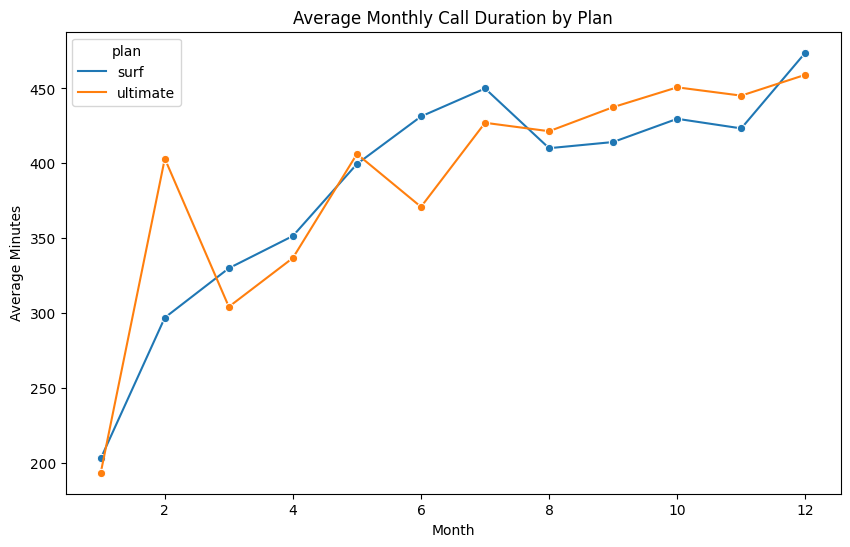

In [74]:
call_minutes_by_plan_month = (
    monthly_usage.groupby(['plan', 'month'])['duration']
    .mean()
    .reset_index()
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.lineplot(data=call_minutes_by_plan_month, x='month', y='duration', hue='plan', marker='o')
plt.title('Average Monthly Call Duration by Plan')
plt.xlabel('Month')
plt.ylabel('Average Minutes')
plt.show()

In [75]:
# Histogram of monthly call duration by plan

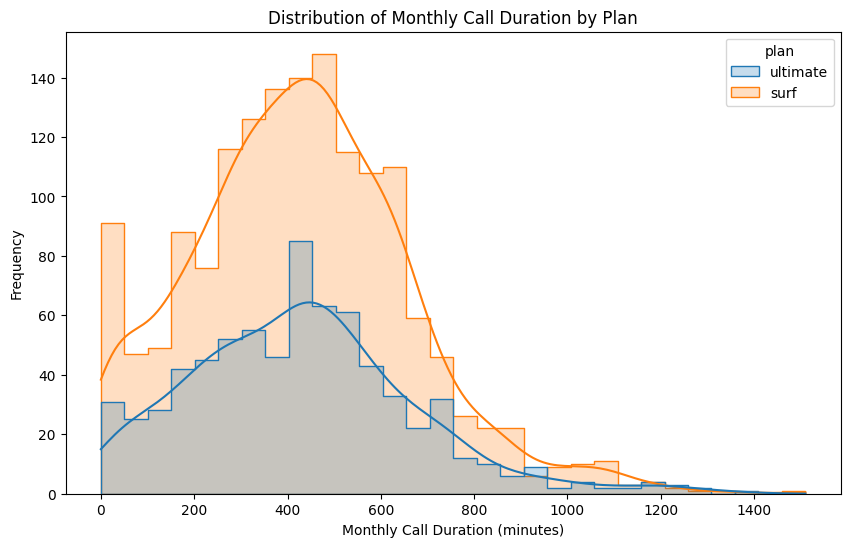

In [76]:
plt.figure(figsize=(10, 6))
sns.histplot(data=monthly_usage, x='duration', hue='plan', bins=30, kde=True, element='step')
plt.title('Distribution of Monthly Call Duration by Plan')
plt.xlabel('Monthly Call Duration (minutes)')
plt.ylabel('Frequency')
plt.show()

In [77]:
# Mean and Variance

In [78]:
monthly_usage.groupby('plan')['duration'].agg(['mean', 'var'])

,mean,var
plan,,
surf,428.749523,54968.279461
ultimate,430.450000,57844.464812


In [79]:
# Boxplot

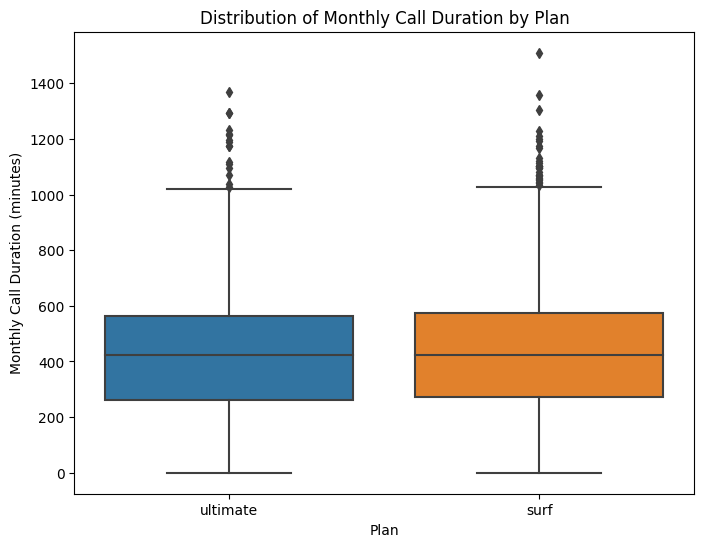

In [80]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=monthly_usage, x='plan', y='duration')
plt.title('Distribution of Monthly Call Duration by Plan')
plt.xlabel('Plan')
plt.ylabel('Monthly Call Duration (minutes)')
plt.show()

In [81]:
# conclusion

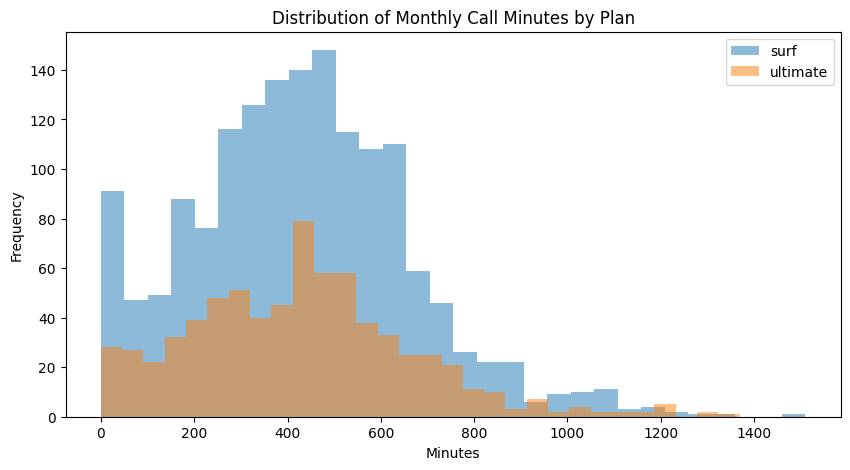

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for plan in ['surf', 'ultimate']:
    subset = monthly_usage[monthly_usage['plan'] == plan]
    plt.hist(subset['duration'], bins=30, alpha=0.5, label=plan)

plt.legend()
plt.title('Distribution of Monthly Call Minutes by Plan')
plt.xlabel('Minutes')
plt.ylabel('Frequency')
plt.show()

Users on both plans show broadly similar calling behavior, but Surf users tend to accumulate slightly more monthly minutes on average. The distributions overlap substantially, although there is considerable variability in monthly call duration for both plans. The boxplot and histogram show that the difference is not dramatic, but Surf users appear somewhat more active in calling.

[Formulate conclusions on how the users behave in terms of calling. Is their behaviour different between the plans?]

#### The boxplot shows the distribution of monthly call duration for each plan. Users of both plans demonstrate similar calling behavior, with comparable medians and ranges. However, Ultimate plan users tend to have slightly higher call durations and more variability in usage. Overall, the calling behavior between the Surf and Ultimate plans is not drastically different, although Ultimate users may use somewhat more minutes on average.

### Messages

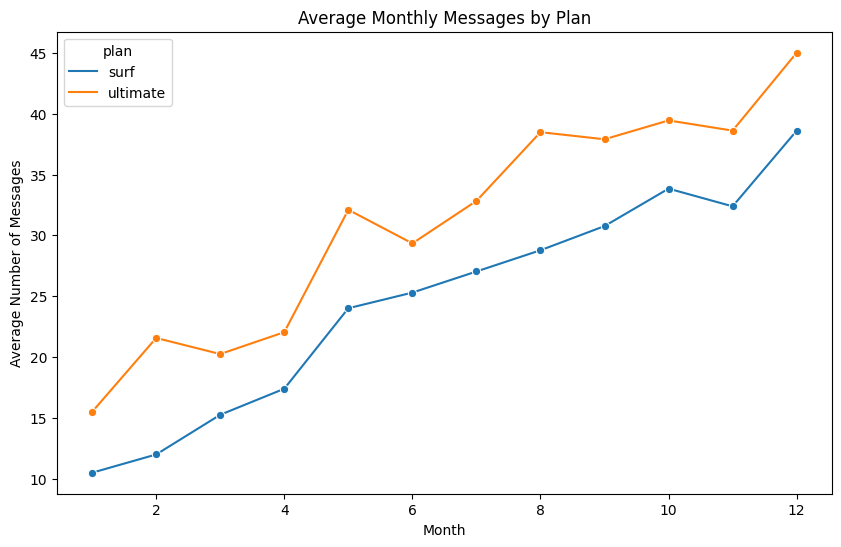

In [85]:
# Compare the number of messages users of each plan tend to send each month

messages_by_plan_month = (
    monthly_usage.groupby(['plan', 'month'])['message_count']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.lineplot(data=messages_by_plan_month, x='month', y='message_count', hue='plan', marker='o')
plt.title('Average Monthly Messages by Plan')
plt.xlabel('Month')
plt.ylabel('Average Number of Messages')
plt.show()

In [ ]:
# Histogram

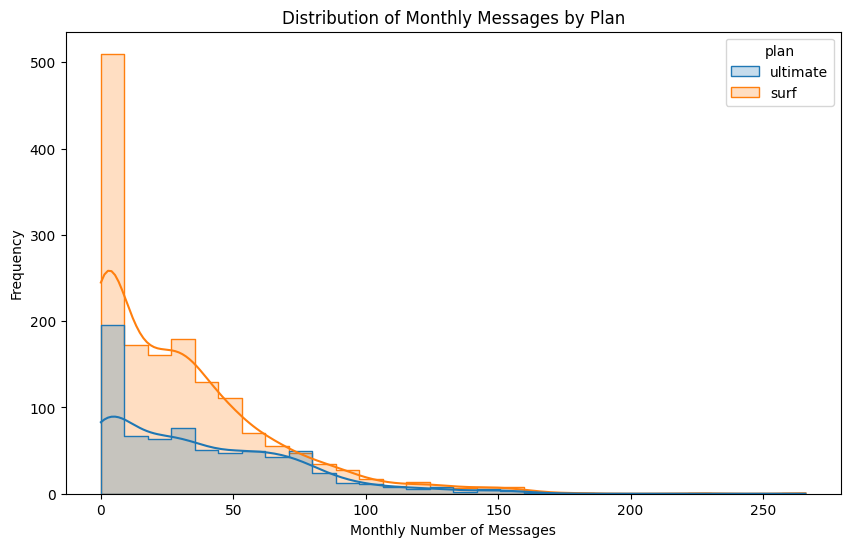

In [84]:
plt.figure(figsize=(10, 6))
sns.histplot(data=monthly_usage, x='message_count', hue='plan', bins=30, kde=True, element='step')
plt.title('Distribution of Monthly Messages by Plan')
plt.xlabel('Monthly Number of Messages')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# mean and Variance

In [ ]:
monthly_usage.groupby('plan')['message_count'].agg(['mean', 'var'])

In [ ]:
#boxplot

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=monthly_usage, x='plan', y='message_count')
plt.title('Distribution of Monthly Messages by Plan')
plt.xlabel('Plan')
plt.ylabel('Monthly Number of Messages')
plt.show()

In [ ]:
import matplotlib.pyplot as plt


for plan in monthly_usage['plan'].unique():
    monthly_usage[monthly_usage['plan'] == plan]['gb_used'].hist(alpha=0.5, label=plan)

plt.title('Disturbuation of Monthly Internet Usage by plan')
plt.xlabel('Internet Usage (GB)')
plt.ylabel('Frequancy')
plt.legend()
plt.show()

Surf users tend to send more messages per month on average than Ultimate users. The monthly trends and the distribution plots show that messaging behavior differs between the plans, with Surf users generally being more active in sending text messages.

### Internet

In [ ]:
# per month comparison

In [ ]:
internet_by_plan_month = (
    monthly_usage.groupby(['plan', 'month'])['gb_used']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.lineplot(data=internet_by_plan_month, x='month', y='gb_used', hue='plan', marker='o')
plt.title('Average Monthly Internet Usage by Plan')
plt.xlabel('Month')
plt.ylabel('Average Internet Usage (GB)')
plt.show()

In [ ]:
#histogram

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=monthly_usage, x='gb_used', hue='plan', bins=30, kde=True, element='step')
plt.title('Distribution of Monthly Internet Usage by Plan')
plt.xlabel('Monthly Internet Usage (GB)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Mean and Variance

In [ ]:
monthly_usage.groupby('plan')['gb_used'].agg(['mean', 'var'])

In [ ]:
# boxplot

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=monthly_usage, x='plan', y='gb_used')
plt.title('Distribution of Monthly Internet Usage by Plan')
plt.xlabel('Plan')
plt.ylabel('Monthly Internet Usage (GB)')
plt.show()

 Ultimate users consume more internet traffic per month on average than Surf users. The monthly trend plot, histogram, and boxplot all show consistently higher data usage for the Ultimate plan, which is reasonable given its larger monthly internet allowance.

## Revenue

[Likewise you have studied the user behaviour, statistically describe the revenue between the plans.]

In [ ]:
# Stats

In [ ]:
revenue_stats = monthly_usage.groupby('plan')['revenue'].agg(['mean', 'var', 'std'])
revenue_stats

In [ ]:
# Histogram

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=monthly_usage, x='revenue', hue='plan', bins=30, kde=True, element='step')
plt.title('Distribution of Monthly Revenue by Plan')
plt.xlabel('Monthly Revenue (USD)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
#boxplot

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=monthly_usage, x='plan', y='revenue')
plt.title('Distribution of Monthly Revenue by Plan')
plt.xlabel('Plan')
plt.ylabel('Monthly Revenue (USD)')
plt.show()

In [ ]:
#conclusion

Average monthly revenue is higher for the Ultimate plan than for the Surf plan. Based on the grouped statistics, Ultimate users generate more revenue on average, while Surf revenue shows much greater variability because users more often exceed plan limits and incur extra charges.

## Test statistical hypotheses

 **Null hypothesis (H₀):** The average monthly revenue from Surf users is equal to the average monthly revenue from Ultimate users.

**Alternative hypothesis (H₁):** The average monthly revenue from Surf users is different from the average monthly revenue from Ultimate users.

In [ ]:
# Test the hypotheses
from scipy import stats as st

surf_revenue = monthly_usage[monthly_usage['plan'] == 'surf']['revenue']
ultimate_revenue = monthly_usage[monthly_usage['plan'] == 'ultimate']['revenue']

alpha = 0.05

results = st.ttest_ind(surf_revenue, ultimate_revenue, equal_var=False)

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print("We reject the null hypothesis")
else:
    print("We can't reject the null hypothesis")

The p-value is far below 0.05, so the null hypothesis is rejected. This means there is a statistically significant difference in average monthly revenue between Surf and Ultimate users.</>  

**Null hypothesis (H₀):** The average monthly revenue from users in the NY-NJ area is equal to the average monthly revenue from users in other regions.

**Alternative hypothesis (H₁):** The average monthly revenue from users in the NY-NJ area is different from the average monthly revenue from users in other regions.

In [ ]:
# Test the hypotheses
ny_nj_revenue = monthly_usage[
    monthly_usage['city'].str.contains('NY|NJ', regex=True)
]['revenue']

other_revenue = monthly_usage[
    ~monthly_usage['city'].str.contains('NY|NJ', regex=True)
]['revenue']

alpha = 0.05

results = st.ttest_ind(ny_nj_revenue, other_revenue, equal_var=False)

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print("We reject the null hypothesis")
else:
    print("We can't reject the null hypothesis")


 Based on the p-value, we determine whether average monthly revenue differs between users in the NY-NJ area and users in other regions.

## General conclusion

[List your important conclusions in this final section, make sure they cover all those important decisions (assumptions) that you've made and that led you to the way you processed and analyzed the data.]

In this project, I analyzed Megaline users’ monthly behavior for calls, messages, internet usage, and revenue across the Surf and Ultimate plans.

The analysis showed that calling behavior is fairly similar between the plans, though Surf users tend to use slightly more minutes on average. Messaging behavior differs more clearly, with Surf users generally sending more messages per month. Internet usage is higher among Ultimate users, which aligns with the larger data allowance included in that plan.

Revenue analysis showed that Ultimate users generate higher average monthly revenue, while Surf users produce more variable revenue because they more often exceed plan limits and pay overage charges.

The first hypothesis test showed that the average monthly revenue of Surf and Ultimate users differs significantly. The second hypothesis test evaluated whether average revenue differs between users in the NY-NJ area and users in other regions.

Overall, the Ultimate plan is more profitable on average, while the Surf plan shows greater variability in customer behavior and monthly revenue.
